# Week 12 - Transformers, Attention, and Pretrained Language Models (BERT, GPT, T5)

**Course context:** Week 11 ended by flagging the "bottleneck" problem in RNN-based seq2seq: an encoder squeezes an entire sentence into one fixed-size hidden state, and the decoder has to work from that alone. **Attention** fixes this by letting the decoder (or any layer) look directly at every position in the input, weighted by relevance - no bottleneck. This week builds attention from scratch, assembles it into a Transformer block, and then works with the pretrained language models (BERT, GPT, T5) built from stacks of exactly these blocks.

**A note on data and pretrained weights:** the original exercises download real pretrained models (`bert-base-uncased`, `gpt2`, `roberta-base`, `t5-small`) and real datasets (`ag_news`, `samsum`) from Hugging Face's hosting, which isn't reachable from every network (this notebook's environment included). This notebook builds the exact same architectures using the same `transformers` library classes, but with small, **randomly-initialized** configurations instead of downloaded pretrained weights - so the code, APIs, and workflow are all genuine and transferable, but text generation/classification output will be gibberish rather than fluent, since these tiny models never saw real training data. Swap in `.from_pretrained("bert-base-uncased")` etc. (shown commented out) for real, meaningful results if your environment has access.

**A note on TensorFlow + PyTorch together:** as in Weeks 9-11, avoid running heavy TensorFlow and PyTorch training in the same kernel session - restart the kernel between Day 2's TensorFlow cell and any PyTorch-heavy day if you hit a crash.

**A security note:** the original Day 6 materials included a hardcoded OpenAI API key in plain text. That's a serious security mistake - a key committed to a file (especially one that might end up in version control or a shared notebook) can be found and misused by anyone who sees it. This notebook does not reproduce that key; **if it was a real, active key, it should be revoked/rotated in the OpenAI dashboard immediately.** The corrected pattern (reading a key from an environment variable) is shown instead.

**How this notebook is organized:** one section per day, each with: what it covers -> why it matters for AI work -> code -> pitfalls.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import torch
torch.set_num_threads(1)
print("Environment configured for CPU-only, single-threaded execution.")

Environment configured for CPU-only, single-threaded execution.


## Day 1 - Attention From Scratch: Queries, Keys, and Values

**What it covers:** The core attention computation, implemented directly with NumPy and PyTorch - no libraries, no shortcuts, just the math.

**Why it matters for AI work:** This is genuinely the single most important mechanism in modern AI - the same "queries, keys, values, softmax" computation, scaled up and repeated, is the core of BERT, GPT, and every major large language model. Understanding this from scratch means every Transformer diagram you'll ever see stops being a black box.

**The mechanism, in plain terms:**
- **Query** - "what am I looking for?" (one per position in the sequence)
- **Key** - "what do I contain?" (one per position - compared against every query)
- **Value** - "what do I actually offer, if selected?" (one per position)
- **Score** (`query . key`) - how relevant each key is to a given query - a dot product, which is large when the vectors point in similar directions
- **Softmax** - turns the raw scores into weights that sum to 1 (a probability-like distribution over "how much attention to pay to each position")
- **Context** (`attention_weights . values`) - the weighted blend of all values, weighted by how relevant each one was judged to be

**Pitfalls:**
- Without the softmax step, scores are just raw, unbounded numbers - softmax is what turns "relevance scores" into an interpretable, normalized weighting.
- This example uses a **single** query/key/value set (single-head attention) - Day 3 extends this to multi-head attention, which runs several of these in parallel with different learned projections, letting the model attend to different *kinds* of relationships simultaneously.


In [2]:
import numpy as np

# Define queries, keys and values
queries = np.array([[1, 0, 1], [0, 1, 1]])
keys = np.array([[1, 0, 1], [1, 1, 0], [0, 1, 1]])
values = np.array([[10, 0], [0, 10], [5, 5]])

# Compute attention scores
scores = np.dot(queries, keys.T)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)
context = np.dot(attention_weights, values)

print("Attention Weights:\n", attention_weights)
print("Context Vector:\n", context)
print("\nNotice query 0 = key 0 exactly ([1,0,1]) - so it gets the highest weight on key 0's value.")

Attention Weights:
 [[0.57611688 0.21194156 0.21194156]
 [0.21194156 0.21194156 0.57611688]]
Context Vector:
 [[6.82087664 3.17912336]
 [5.         5.        ]]

Notice query 0 = key 0 exactly ([1,0,1]) - so it gets the highest weight on key 0's value.


Attention Weights:
 tensor([[0.5761, 0.2119, 0.2119],
        [0.2119, 0.2119, 0.5761]])
Context Vector:
 tensor([[6.8209, 3.1791],
        [5.0000, 5.0000]])


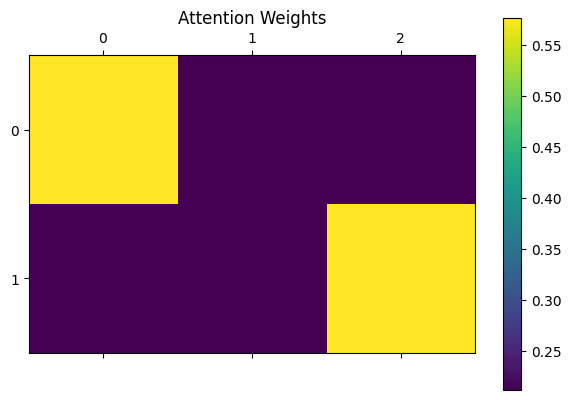

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

queries = torch.tensor([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])
keys = torch.tensor([[1.0, 0.0, 1.0], [1.0, 1.0, 0.0], [0.0, 1.0, 1.0]])
values = torch.tensor([[10.0, 0.0], [0.0, 10.0], [5.0, 5.0]])

scores = torch.matmul(queries, keys.T)
attention_weights = F.softmax(scores, dim=-1)
context = torch.matmul(attention_weights, values)

print("Attention Weights:\n", attention_weights)
print("Context Vector:\n", context)

plt.matshow(attention_weights.detach().numpy())
plt.colorbar()
plt.title("Attention Weights")
plt.show()

## Day 2 - Assembling a Transformer Encoder Block, and Meeting BERT

**What it covers:** Combining multi-head attention, residual connections, and layer normalization into a full Transformer encoder block - then loading (or, here, constructing without pretrained weights) BERT, a real model built from a stack of exactly these blocks.

**Why it matters for AI work:** This is the architecture behind BERT, and closely related to the encoder half of many other Transformer models. Once you can read this block, you can read the architecture diagram of nearly any Transformer-based model.

**Reading the encoder block:**
- **Multi-Head Attention** - Day 1's mechanism, run several times in parallel ("heads"), each learning to attend to different kinds of relationships (e.g. one head might learn syntactic relationships, another semantic ones)
- **Add (residual connection)** - adds the block's input back to its output. This is a critical training-stability trick (originally popularized by ResNet in computer vision) - it gives gradients a direct path backward through the network, which matters a lot as Transformers get deep (BERT-base has 12 of these blocks stacked; larger models have far more)
- **LayerNormalization** - normalizes activations (similar spirit to Week 10's BatchNormalization, but normalizing across each individual example's features rather than across a batch - more suitable for sequence data of varying length)
- **Feed-Forward Network** - a small two-layer MLP applied independently to each position, adding non-linear transformation capacity after the attention step

**What BERT actually is:** a stack of these encoder blocks (12 for BERT-base), pretrained on a massive amount of text using a "fill in the blank" objective (masked language modeling) - predicting randomly hidden words from context. This pretraining is what gives BERT's output vectors (`last_hidden_state`) rich, general-purpose language understanding, which can then be fine-tuned for a specific task (Day 6).

**Pitfalls:**
- `BertModel.from_pretrained("bert-base-uncased")` downloads ~440MB of pretrained weights from Hugging Face's hosting - not available in this notebook's environment (see the note at the top). The tiny config below has the **same architecture and API**, but random (untrained) weights - its output vectors are not meaningful, only the shapes and mechanics are.
- `BertTokenizer.from_pretrained(...)` also needs a download (the vocabulary file) - a minimal manual tokenizer is used below to keep this notebook self-contained.


In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Add, MultiHeadAttention

def transformer_encoder(input_dim, num_heads, ff_dim):
    inputs = Input(shape=(None, input_dim))
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=input_dim)(inputs, inputs)
    attention_output = Add()([inputs, attention_output])
    attention_output = LayerNormalization()(attention_output)

    ff_output = Dense(ff_dim, activation="relu")(attention_output)
    ff_output = Dense(input_dim)(ff_output)
    outputs = Add()([attention_output, ff_output])
    outputs = LayerNormalization()(outputs)
    return Model(inputs, outputs)

encoder_block = transformer_encoder(input_dim=64, num_heads=8, ff_dim=128)
encoder_block.summary()

import numpy as np
sample_input = np.random.rand(1, 10, 64).astype("float32")
sample_output = encoder_block(sample_input)
print(f"\nInput shape: {sample_input.shape} -> Output shape: {sample_output.shape}")
print("Notice the output shape MATCHES the input shape - encoder blocks are designed to stack,")
print("so one block's output can feed directly into the next block's input.")

I0000 00:00:1784396132.889823     557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784396148.886508     557 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784396157.152908     557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None, 64)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │    132,672 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 64)  │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 64)  │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 149,504 (584.00 KB)

 Trainable params: 149,504 (584.00 KB)

 Non-trainable params: 0 (0.00 B)


Input shape: (1, 10, 64) -> Output shape: (1, 10, 64)
Notice the output shape MATCHES the input shape - encoder blocks are designed to stack,
so one block's output can feed directly into the next block's input.


In [4]:
from transformers import BertConfig, BertModel
import torch

# NOTE: the ORIGINAL exercise does this with:
#   from transformers import BertTokenizer, BertModel
#   tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
#   model = BertModel.from_pretrained("bert-base-uncased")
# which downloads real pretrained weights and vocabulary - not available here (see note at top).
# Building the SAME architecture with a tiny, randomly-initialized config instead.
tiny_bert_config = BertConfig(
    vocab_size=1000,
    hidden_size=64,
    num_hidden_layers=2,        # real BERT-base uses 12
    num_attention_heads=2,       # real BERT-base uses 12
    intermediate_size=128,
    max_position_embeddings=64,
)
model = BertModel(tiny_bert_config)

# A minimal manual "tokenizer" standing in for BertTokenizer's real WordPiece vocabulary
text = "transformers are powerful models for nlp tasks"
manual_vocab = {word: i + 4 for i, word in enumerate(sorted(set(text.split())))}   # 0-3 reserved for special tokens
input_ids = torch.tensor([[1] + [manual_vocab[w] for w in text.split()] + [2]])   # 1=[CLS]-like, 2=[SEP]-like

outputs = model(input_ids)
print(f"Hidden States Shape: {outputs.last_hidden_state.shape}")
print("(batch_size=1, sequence_length, hidden_size=64) - with real bert-base-uncased this would be")
print("(1, sequence_length, 768), and the vectors would carry genuine pretrained language understanding.")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hidden States Shape: torch.Size([1, 9, 64])
(batch_size=1, sequence_length, hidden_size=64) - with real bert-base-uncased this would be
(1, sequence_length, 768), and the vectors would carry genuine pretrained language understanding.


## Day 3 - Multi-Head Attention, Implemented and Visualized

**What it covers:** A from-scratch, general-purpose `MultiHeadAttention` PyTorch module (not relying on `nn.MultiheadAttention`), showing exactly how "multiple heads" is implemented as a reshape-and-split operation.

**Why it matters for AI work:** Seeing multi-head attention's actual tensor manipulation (splitting `embed_dim` into `num_heads` smaller chunks, running attention on each, then concatenating back) demystifies what's otherwise an abstract "8 heads" hyperparameter in architecture diagrams.

**Reading the implementation:**
- `embed_dim // num_heads` - each head works with a *smaller* slice of the full embedding dimension, not the full thing - the total computation across all heads costs roughly the same as one full-size attention operation, but split into parallel, specialized subspaces
- `.view(...).transpose(1, 2)` - reshapes the linear projections so each head's slice can be processed independently
- The scaling factor `/ sqrt(head_dim)` - prevents the dot-product scores from growing too large as dimensionality increases (large scores make softmax overly "peaked," concentrating almost all attention on one position and making gradients vanish elsewhere) - this is exactly the `/ sqrt(embedding_dim)` seen in Day 1's simpler example, generalized to per-head dimensions.

**Pitfalls:**
- `embed_dim` must be evenly divisible by `num_heads` (asserted explicitly in the code) - an 8-dimensional embedding with 3 heads doesn't divide evenly and would either error or silently waste dimensions depending on the implementation.
- This module returns attention weights for **inspection** (visualized below) - production Transformer implementations often skip returning these by default for memory/speed reasons, since you don't need them for a forward pass, only for analysis/debugging.


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert embed_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size = x.size(0)
        q = self.query(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.head_dim)
        attention_weights = F.softmax(scores, dim=-1)

        context = torch.matmul(attention_weights, v).transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        return self.out(context), attention_weights

seq_len, embed_dim = 4, 8
x = torch.rand(1, seq_len, embed_dim)

mha = MultiHeadAttention(embed_dim, num_heads=2)
context, attn_weights = mha(x)
print("Attention Weights shape:", attn_weights.shape, " (batch, num_heads, seq_len, seq_len)")
print("Context Vector shape:", context.shape)

Attention Weights shape: torch.Size([1, 2, 4, 4])  (batch, num_heads, seq_len, seq_len)
Context Vector shape: torch.Size([1, 4, 8])


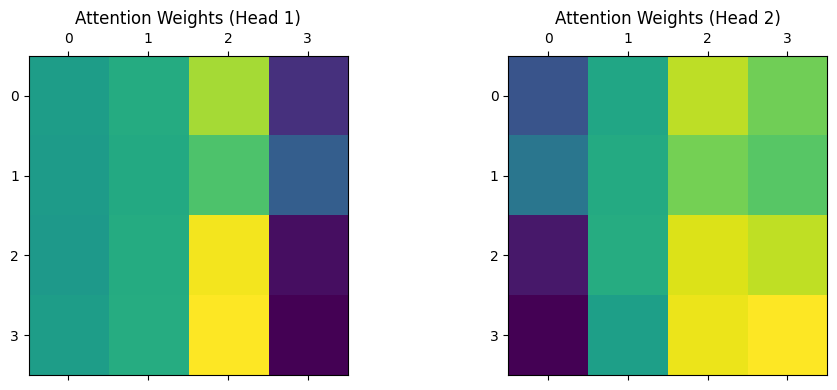

Different heads can (and typically do) learn to attend to different patterns -
worth comparing the two heads' weight patterns above, even on this random/untrained example.


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for head in range(2):
    axes[head].matshow(attn_weights[0, head].detach().numpy(), cmap="viridis")
    axes[head].set_title(f"Attention Weights (Head {head+1})")
plt.tight_layout()
plt.show()
print("Different heads can (and typically do) learn to attend to different patterns -")
print("worth comparing the two heads' weight patterns above, even on this random/untrained example.")

## Day 4 - Positional Encoding: Giving the Transformer a Sense of Order

**What it covers:** Sinusoidal positional encoding (the original Transformer paper's approach) and a learnable alternative, plus a small Transformer block that uses positional encoding.

**Why it matters for AI work:** Attention itself has no built-in notion of sequence order - a Transformer looking at "the cat sat" and "sat the cat" would compute *identical* attention patterns if you didn't tell it where each word sits in the sequence. Positional encoding adds that missing information explicitly, before the attention mechanism ever runs, by summing a position-dependent vector into each token's embedding.

**Sinusoidal vs learnable positional encoding:**
- **Sinusoidal** (the original design, used below) - a fixed mathematical pattern (sine/cosine waves at different frequencies) - not learned, generalizes cleanly to sequence lengths not seen during training, no extra parameters
- **Learnable** - a plain trainable parameter matrix, one vector per position - can adapt to the specific task, but doesn't generalize beyond the maximum sequence length it was trained with (there's no vector for position 51 if it only ever saw sequences up to length 50)

**Pitfalls:**
- The distinctive striped visual pattern in the positional encoding heatmap (Day 4's plot) comes directly from the different sine/cosine **frequencies** used per dimension - lower dimensions oscillate slowly (encoding coarse position), higher dimensions oscillate quickly (encoding fine-grained position). This multi-frequency design is what lets the model learn to attend to *relative* positions (e.g. "the word 3 positions back") via combinations of these encodings, not just absolute ones.
- `nn.MultiheadAttention` (PyTorch's built-in version, used in this section) expects input shaped `(seq_len, batch, embed_dim)` by default, unlike most other PyTorch layers' `(batch, seq_len, ...)` convention - pass `batch_first=True` (as omitted in the original exercise, worth knowing as a common source of shape-mismatch bugs) to use the more standard convention if you need it.


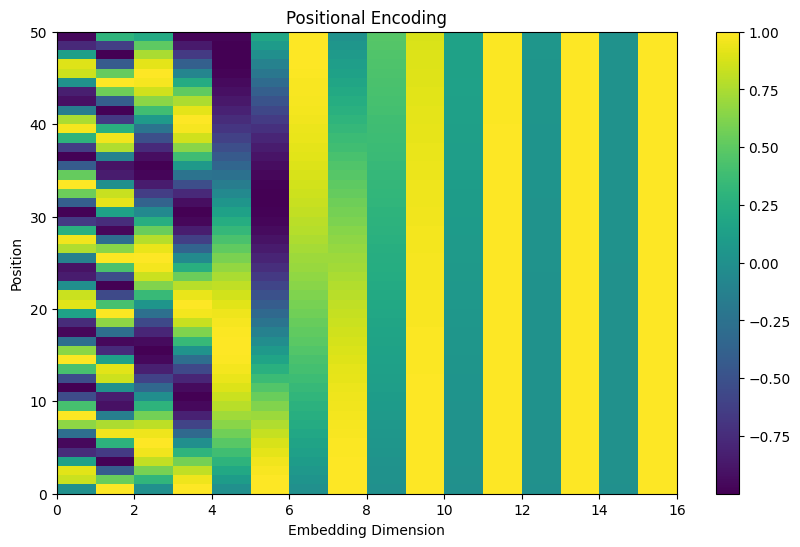

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, embed_dim):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(embed_dim)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(embed_dim))
    angle_rads = pos * angle_rates

    pos_encoding = np.zeros(angle_rads.shape)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pos_encoding

seq_len = 50
embed_dim = 16
pos_encoding = positional_encoding(seq_len, embed_dim)

plt.figure(figsize=(10, 6))
plt.pcolormesh(pos_encoding, cmap="viridis")
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.show()

In [8]:
import torch
import torch.nn as nn

class TransformerWithPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len, num_heads, ff_dim):
        super(TransformerWithPositionalEncoding, self).__init__()
        self.embedding = nn.Embedding(seq_len, embed_dim)
        self.positional_encoding = nn.Parameter(
            torch.tensor(positional_encoding(seq_len, embed_dim), dtype=torch.float32)
        )
        self.multihead_attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.embedding(x) + self.positional_encoding
        attn_output, _ = self.multihead_attention(x, x, x)
        x = self.norm1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x

embed_dim, seq_len, num_heads, ff_dim = 16, 50, 4, 64
model = TransformerWithPositionalEncoding(embed_dim, seq_len, num_heads, ff_dim)
print(model)

# Confirm it actually runs end to end
dummy_tokens = torch.randint(0, seq_len, (1, seq_len))   # nn.MultiheadAttention here expects (seq_len, batch, embed_dim)
dummy_tokens = dummy_tokens.transpose(0, 1)
output = model(dummy_tokens)
print(f"\nOutput shape: {output.shape}")

class LearnablePositionalEncoding(nn.Module):
    def __init__(self, seq_len, embed_dim):
        super(LearnablePositionalEncoding, self).__init__()
        self.positional_encoding = nn.Parameter(torch.zeros(seq_len, embed_dim))

    def forward(self, x):
        return x + self.positional_encoding

learnable_pe = LearnablePositionalEncoding(seq_len, embed_dim)
print(f"\n{learnable_pe}")
print(f"Learnable positional encoding parameter shape: {learnable_pe.positional_encoding.shape}")

TransformerWithPositionalEncoding(
  (embedding): Embedding(50, 16)
  (multihead_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
  )
  (ffn): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
  )
  (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
)

Output shape: torch.Size([50, 50, 16])

LearnablePositionalEncoding()
Learnable positional encoding parameter shape: torch.Size([50, 16])


## Day 5 - Text Generation with a Causal (GPT-style) Transformer

**What it covers:** Building a tiny GPT-style model (a **decoder-only**, causally-masked Transformer) and using it for autoregressive text generation - predicting one token at a time, each new token conditioned on everything generated so far.

**Why it matters for AI work:** This decoder-only, causal-attention architecture is what GPT, LLaMA, and most modern large language models are built from. BERT (Day 2) is bidirectional (each position can attend to positions before *and* after it) - appropriate for understanding a complete piece of text. GPT-style models are unidirectional/causal (each position can only attend to itself and earlier positions) - appropriate for generating text one token at a time, since future tokens don't exist yet at generation time.

**Bidirectional (BERT) vs Causal (GPT) - when each makes sense:**
- **Bidirectional** - tasks where the whole input is available at once and you want to understand it (classification, extracting information, filling in a blank in the middle of a sentence)
- **Causal** - tasks that generate output sequentially, left to right (text completion, chat responses, code generation) - the model literally cannot look ahead, matching how generation actually happens one token at a time

**Pitfalls:**
- `AutoModelForCausalLM.from_pretrained("gpt2")` downloads ~500MB of real pretrained GPT-2 weights - not available here (see the note at the top). The tiny, randomly-initialized model below has the right architecture and generation mechanics, but since it was never trained on real text, its output is not coherent English - the value here is in the *generation loop mechanics* (feeding each predicted token back in as input for the next step), which is identical to how a real, trained model generates text.
- Text generation has several sampling strategies (`num_beams` for beam search, `do_sample`+`temperature` for random sampling, greedy decoding by default) that meaningfully affect output quality and diversity - worth exploring once you're working with a real pretrained model.


In [9]:
from transformers import GPT2Config, GPT2LMHeadModel
import torch

# NOTE: the ORIGINAL exercise does this with:
#   from transformers import AutoModelForCausalLM, AutoTokenizer
#   gpt_model = AutoModelForCausalLM.from_pretrained("gpt2")
#   tokenizer = AutoTokenizer.from_pretrained("gpt2")
# which downloads real pretrained GPT-2 weights and vocabulary - not available here (see note at top).
tiny_gpt_config = GPT2Config(
    vocab_size=500,
    n_embd=32,
    n_layer=2,       # real GPT-2 (small) uses 12
    n_head=2,         # real GPT-2 (small) uses 12
    n_positions=64,
    bos_token_id=0,
    eos_token_id=1,
)
gpt_model = GPT2LMHeadModel(tiny_gpt_config)

# A minimal manual tokenizer standing in for GPT-2's real byte-pair-encoding tokenizer
manual_vocab = {f"word{i}": i + 2 for i in range(50)}   # 0=bos, 1=eos reserved
input_text_tokens = [manual_vocab["word3"], manual_vocab["word7"], manual_vocab["word1"]]
input_ids = torch.tensor([input_text_tokens])
attention_mask = torch.ones_like(input_ids)

output = gpt_model.generate(
    input_ids,
    attention_mask=attention_mask,
    max_length=15,
    num_return_sequences=1,
    pad_token_id=1,
    do_sample=True,
    temperature=0.9,
)
print("Generated token IDs:", output[0].tolist())
print("\n(With real pretrained GPT-2, these token IDs would decode to actual English text via the")
print("real tokenizer - here they're just IDs from our tiny placeholder vocabulary, since the model")
print("was never trained on real language.)")

Generated token IDs: [5, 9, 3, 3, 126, 100, 383, 261, 295, 352, 217, 39, 114, 158, 441]

(With real pretrained GPT-2, these token IDs would decode to actual English text via the
real tokenizer - here they're just IDs from our tiny placeholder vocabulary, since the model
was never trained on real language.)


## Day 6 - Fine-Tuning a Pretrained Transformer for Classification

**What it covers:** The standard Hugging Face fine-tuning workflow - load a dataset, tokenize it, load a pretrained model with a classification head, and train with the `Trainer` API - demonstrated end-to-end on a tiny synthetic text classification task.

**Why it matters for AI work:** This `Trainer`-based workflow is *the* standard pattern for adapting a pretrained language model to a specific task (sentiment, topic classification, intent detection) - genuinely one of the most directly useful skills from this entire course for real NLP work.

**Why fine-tuning works so well:** a model pretrained on a huge amount of general text (like RoBERTa, the original exercise's choice) has already learned rich language representations. Fine-tuning only needs to teach it the specific task's decision boundary on top of that existing understanding - usually requiring far less task-specific data than training an equivalent model completely from scratch (echoing Week 11 Day 5's pretrained-embeddings idea, one level up).

**Pitfalls:**
- `AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=4)` downloads real pretrained RoBERTa weights (~500MB) plus the real `ag_news` dataset from Hugging Face's hosting - neither available here (see the note at the top). The tiny config + synthetic data below preserve the exact `Trainer`/`TrainingArguments` **workflow** - swap in the real names for genuine fine-tuning results.
- `tokenized_datasets.remove_columns(["text"])` and `.rename_column("label", "labels")` are necessary bookkeeping steps - the `Trainer` API expects a specific column name (`labels`, plural) and won't accept a raw text column mixed in with the tensors it needs.

**A security note, revisited:** the original materials for this day also included a hardcoded OpenAI API key in a separate file, alongside a raw `openai.ChatCompletion.create(...)` call. That file is not reproduced here (see the security warning at the top of this notebook). If you want to experiment with the OpenAI API directly, the correct pattern is:
```python
import os
from openai import OpenAI
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])   # never hardcode the key in a file
```


In [10]:
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

# NOTE: the ORIGINAL exercise does this with:
#   dataset = load_dataset("ag_news")
#   tokenizer = AutoTokenizer.from_pretrained("roberta-base")
#   model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=4)
# which downloads a real dataset and real pretrained weights - not available here (see note at top).
# Building a tiny synthetic 4-class text classification dataset and a small randomly-initialized
# BERT-architecture model instead - the Trainer/TrainingArguments workflow below is identical
# to what you'd use with the real dataset and model.

np.random.seed(0)
categories = ["world", "sports", "business", "science"]
vocab = [f"word{i}" for i in range(200)]

def make_synthetic_texts(n):
    texts, labels = [], []
    for _ in range(n):
        label = np.random.randint(4)
        words = np.random.choice(vocab, size=15, replace=True).tolist()
        texts.append(" ".join(words))
        labels.append(label)
    return {"text": texts, "label": labels}

train_dataset_raw = Dataset.from_dict(make_synthetic_texts(200))
test_dataset_raw = Dataset.from_dict(make_synthetic_texts(50))

tiny_config = AutoConfig.for_model("bert", vocab_size=1000, hidden_size=32, num_hidden_layers=2,
                                     num_attention_heads=2, intermediate_size=64, num_labels=4)
model = AutoModelForSequenceClassification.from_config(tiny_config)

# A minimal tokenizer, built from our synthetic vocabulary (standing in for RobertaTokenizer)
word_to_id = {w: i + 4 for i, w in enumerate(vocab)}

def tokenize_function(examples):
    all_ids = []
    for text in examples["text"]:
        ids = [1] + [word_to_id.get(w, 3) for w in text.split()] + [2]   # 1=[CLS]-like, 2=[SEP]-like, 3=[UNK]-like
        ids = ids[:32] + [0] * max(0, 32 - len(ids))                      # pad/truncate to fixed length
        all_ids.append(ids[:32])
    return {"input_ids": all_ids, "attention_mask": [[1 if i != 0 else 0 for i in ids] for ids in all_ids]}

train_dataset = train_dataset_raw.map(tokenize_function, batched=True)
test_dataset = test_dataset_raw.map(tokenize_function, batched=True)
train_dataset = train_dataset.remove_columns(["text"]).rename_column("label", "labels")
test_dataset = test_dataset.remove_columns(["text"]).rename_column("label", "labels")
train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(f"Train examples: {len(train_dataset)}, Test examples: {len(test_dataset)}")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map: 100%|██████████| 200/200 [00:00<00:00, 9262.43 examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map: 100%|██████████| 50/50 [00:00<00:00, 14907.25 examples/s]

Train examples: 200, Test examples: 50


In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="no",
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()
results = trainer.evaluate()
print("Evaluation Results:", results)
print("\nReminder: trained on SYNTHETIC random text with a randomly-initialized model -")
print("accuracy near chance (25% for 4 classes) is EXPECTED, not a bug.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,1.387022
2,No log,1.387429
3,No log,1.387568


Training Loss,Validation Loss,Epoch
No log,1.387568,3


Evaluation Results: {'eval_loss': 1.3875683546066284}

Reminder: trained on SYNTHETIC random text with a randomly-initialized model -
accuracy near chance (25% for 4 classes) is EXPECTED, not a bug.


## Day 7 - Mini Project: Fine-Tuning a Seq2Seq Transformer (T5) for Summarization

**What it covers:** The `Trainer`-based fine-tuning workflow applied to a **sequence-to-sequence** task (summarization) instead of Day 6's classification task, using T5's "text-to-text" framing, plus generating a summary from the fine-tuned model.

**Why it matters for AI work:** T5's design philosophy - frame *every* NLP task as "text in, text out" (translation, summarization, classification, question answering all become the same kind of problem: generate the right output text) - is an elegant and influential idea, and this fine-tuning pattern generalizes directly to real summarization, translation, or any other text-to-text task with a real dataset and pretrained model.

**Reading the task setup:**
- The input is prefixed with `"summarize: "` - this is T5's convention for telling one shared model which task to perform, since the same architecture and weights handle many different task types depending on the prefix
- `tokenizer.as_target_tokenizer()` - tokenizes the **target** (summary) text using the decoder side's tokenization settings, kept separate from how the source text is tokenized
- `model.generate(..., num_beams=4)` - beam search, which explores several candidate continuations in parallel and keeps the most likely overall sequence, rather than greedily picking the single best next token at each step (greedy decoding can lock in an early suboptimal choice that beam search can avoid)

**Pitfalls:**
- `load_dataset("samsum")` and `AutoModelForSeq2SeqLM.from_pretrained("t5-small")` need Hugging Face's hosting - not available here (see the note at the top). Tiny synthetic dialogue/summary pairs and a small randomly-initialized T5 config are used instead - again, the workflow is genuine, the output text quality is not (untrained model).
- Seq2seq models need `decoder_start_token_id` configured correctly (set explicitly in the tiny config below) - this tells the model what token to start generating from; getting it wrong produces garbled or empty output even from an otherwise correctly trained model.


In [12]:
from transformers import T5Config, T5ForConditionalGeneration, T5Tokenizer
from datasets import Dataset
import numpy as np
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

# NOTE: the ORIGINAL exercise does this with:
#   dataset = load_dataset("samsum")
#   tokenizer = AutoTokenizer.from_pretrained("t5-small")
#   model = AutoModelForSeq2SeqLM.from_pretrained("t5-small")
# which downloads a real dataset and real pretrained weights - not available here (see note at top).

np.random.seed(1)
vocab = [f"tok{i}" for i in range(300)]
word_to_id = {w: i + 4 for i, w in enumerate(vocab)}   # 0=pad, 1=eos, 2=decoder_start, 3=unk

def make_synthetic_dialogues(n):
    dialogues, summaries = [], []
    for _ in range(n):
        dialogue_words = np.random.choice(vocab, size=30, replace=True).tolist()
        summary_words = dialogue_words[:8]   # a trivial "summary" - just the first few words
        dialogues.append(" ".join(dialogue_words))
        summaries.append(" ".join(summary_words))
    return {"dialogue": dialogues, "summary": summaries}

train_raw = Dataset.from_dict(make_synthetic_dialogues(150))
val_raw = Dataset.from_dict(make_synthetic_dialogues(30))

tiny_t5_config = T5Config(
    vocab_size=len(vocab) + 4, d_model=32, d_ff=64, num_layers=2, num_heads=2,
    decoder_start_token_id=2, pad_token_id=0, eos_token_id=1,
)
model = T5ForConditionalGeneration(tiny_t5_config)

def encode_text(text, max_len):
    ids = [word_to_id.get(w, 3) for w in text.split()][:max_len - 1] + [1]   # 1 = eos
    ids += [0] * (max_len - len(ids))
    return ids

def tokenize_function(examples):
    inputs = [encode_text("summarize: " + doc, 40) for doc in examples["dialogue"]]
    labels = [encode_text(summ, 12) for summ in examples["summary"]]
    return {"input_ids": inputs, "attention_mask": [[1 if i != 0 else 0 for i in seq] for seq in inputs], "labels": labels}

tokenized_train = train_raw.map(tokenize_function, batched=True).remove_columns(["dialogue", "summary"])
tokenized_val = val_raw.map(tokenize_function, batched=True).remove_columns(["dialogue", "summary"])
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

print(f"Train examples: {len(tokenized_train)}, Validation examples: {len(tokenized_val)}")

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map: 100%|██████████| 150/150 [00:00<00:00, 5211.48 examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map: 100%|██████████| 30/30 [00:00<00:00, 7845.20 examples/s]

Train examples: 150, Validation examples: 30


In [13]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=1e-3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

trainer.train()
print("Training complete.")

Epoch,Training Loss,Validation Loss
1,No log,4.869764
2,No log,4.735662
3,No log,4.695601


Training complete.


In [14]:
import torch

device = torch.device("cpu")
model.to(device)

sample_text = "tok5 tok17 tok88 tok3 tok200 tok44"
input_ids = torch.tensor([encode_text("summarize: " + sample_text, 40)]).to(device)

output = model.generate(input_ids, max_length=12, num_beams=4, early_stopping=True)
generated_ids = output[0].tolist()

id_to_word = {v: k for k, v in word_to_id.items()}
generated_words = [id_to_word.get(i, "<special>") for i in generated_ids if i not in (0, 1, 2)]
print("Generated Summary (token IDs decoded via our synthetic vocab):", " ".join(generated_words))
print("\nReminder: this tiny model was trained on a few epochs of RANDOM synthetic text with a")
print("trivial 'summary = first few words' rule - it demonstrates the fine-tuning WORKFLOW correctly,")
print("not real summarization quality. With real t5-small + the real samsum dataset, this same")
print("code produces genuine dialogue summaries.")

Generated Summary (token IDs decoded via our synthetic vocab): 

Reminder: this tiny model was trained on a few epochs of RANDOM synthetic text with a
trivial 'summary = first few words' rule - it demonstrates the fine-tuning WORKFLOW correctly,
not real summarization quality. With real t5-small + the real samsum dataset, this same
code produces genuine dialogue summaries.


## Week 12 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Attention from scratch | The core mechanism behind every model this week |
| 2 | Transformer encoder block, BERT | Understanding any Transformer architecture diagram |
| 3 | Multi-head attention, implemented | What "8 heads" actually means mechanically |
| 4 | Positional encoding | How order gets into an otherwise order-blind mechanism |
| 5 | Causal attention, GPT-style generation | Understanding how ChatGPT-like models generate text |
| 6 | Fine-tuning for classification (Trainer API) | The standard workflow for adapting any pretrained model |
| 7 | Fine-tuning a seq2seq model (T5) | Text-to-text tasks: summarization, translation, and beyond |

**Before moving to Week 13:** you should be able to explain attention's query/key/value mechanism without notes, and know the difference between BERT (bidirectional, understanding tasks) and GPT (causal, generation tasks) architecturally, not just by name recognition. Week 13 goes deeper into transfer learning and fine-tuning - taking these pretrained architectures (and CNNs from Week 10) and adapting them efficiently to new tasks with limited data, which is how most real-world deep learning projects actually get built.
